In [1]:
# Monter le drive
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_ROOT = '/content/drive/MyDrive/Projet_annuel/Dataset/CUB_200_2011'
print(os.listdir(DATA_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['attributes.txt', 'CUB_200_2011']


In [2]:
DATA_ROOT = '/content/drive/MyDrive/Projet_annuel/Dataset/CUB_200_2011/CUB_200_2011'
print(os.listdir(DATA_ROOT))

['images.txt', 'train_test_split.txt', 'classes.txt', 'bounding_boxes.txt', 'image_class_labels.txt', 'README', 'images', 'attributes', 'parts']


### chargement et fusion des métadonnées

In [3]:
import pandas as pd

images = pd.read_csv(f'{DATA_ROOT}/images.txt', sep=' ', names=['image_id', 'image_name'])
labels = pd.read_csv(f'{DATA_ROOT}/image_class_labels.txt', sep=' ', names=['image_id', 'class_id'])
classes = pd.read_csv(f'{DATA_ROOT}/classes.txt', sep=' ', names=['class_id', 'class_name'])
split = pd.read_csv(f'{DATA_ROOT}/train_test_split.txt', sep=' ', names=['image_id', 'is_training'])

df = images.merge(labels, on='image_id').merge(classes, on='class_id').merge(split, on='image_id')
df['image_path'] = df['image_name'].apply(lambda x: f'{DATA_ROOT}/images/{x}')

print(df.shape)  # attendu : (11788, 6)
df.head()

(11788, 6)


,image_id,image_name,class_id,class_name,is_training,image_path
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,/content/drive/MyDrive/Projet_annuel/Dataset/C...
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/content/drive/MyDrive/Projet_annuel/Dataset/C...
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,/content/drive/MyDrive/Projet_annuel/Dataset/C...
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/content/drive/MyDrive/Projet_annuel/Dataset/C...
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/content/drive/MyDrive/Projet_annuel/Dataset/C...


### vérification d'intégrité + sauvegarde

In [4]:
missing = df[~df['image_path'].apply(os.path.exists)]
print(f"Images manquantes : {len(missing)}")
print(f"Nb classes : {df['class_id'].nunique()}")  # attendu : 200
print(f"Train / Test : {df['is_training'].value_counts().to_dict()}")

OUT_DIR = '/content/drive/MyDrive/Projet_annuel/data_processed'
os.makedirs(OUT_DIR, exist_ok=True)
df.to_csv(f'{OUT_DIR}/metadata.csv', index=False)

Images manquantes : 0
Nb classes : 200
Train / Test : {1: 5994, 0: 5794}


### EDA 1 — distribution des classes

Min: 41, Max: 60, Moyenne: 58.9


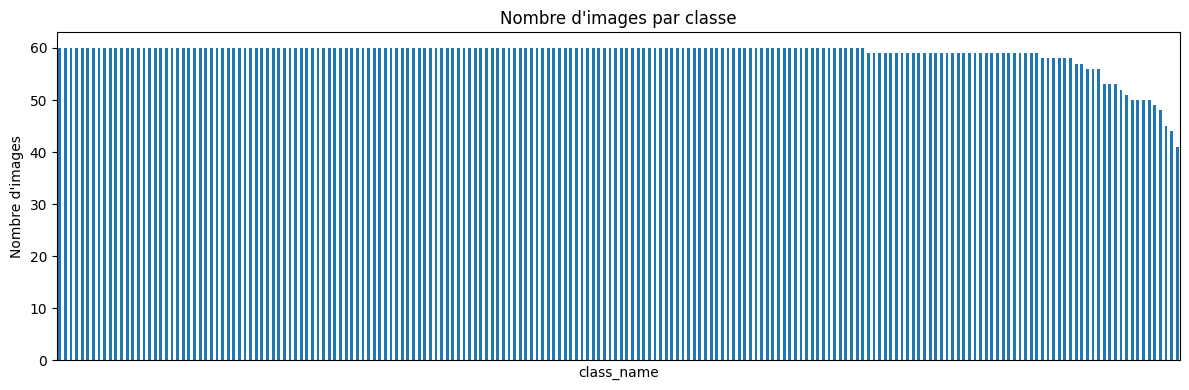

In [5]:
import matplotlib.pyplot as plt

counts = df['class_name'].value_counts()
print(f"Min: {counts.min()}, Max: {counts.max()}, Moyenne: {counts.mean():.1f}")

plt.figure(figsize=(12,4))
counts.plot(kind='bar')
plt.xticks([])
plt.title("Nombre d'images par classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_class_distribution.png', dpi=200)
plt.show()

### EDA 2 — résolution des images (échantillon de 500)

In [6]:
from PIL import Image
import numpy as np

sample = df.sample(n=500, random_state=42)
widths, heights = [], []
for path in sample['image_path']:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths, heights = np.array(widths), np.array(heights)
print(f"Largeur — min: {widths.min()}, max: {widths.max()}, moyenne: {widths.mean():.0f}")
print(f"Hauteur — min: {heights.min()}, max: {heights.max()}, moyenne: {heights.mean():.0f}")

Largeur — min: 140, max: 500, moyenne: 471
Hauteur — min: 149, max: 500, moyenne: 384


### EDA 3 — classes visuellement proches

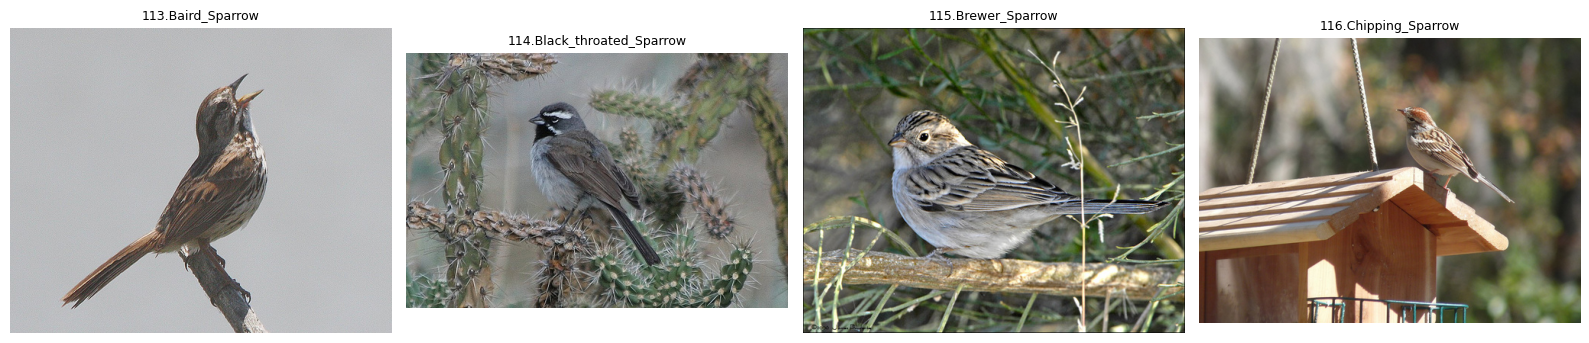

In [7]:
similar_classes = df[df['class_name'].str.contains('_Sparrow', case=False)]['class_name'].unique()[:4]

fig, axes = plt.subplots(1, len(similar_classes), figsize=(16,4))
for ax, cls in zip(axes, similar_classes):
    example_path = df[df['class_name'] == cls]['image_path'].iloc[0]
    img = Image.open(example_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_similar_classes.png', dpi=200)
plt.show()

### split train / val / test

In [8]:
from sklearn.model_selection import train_test_split

SEED = 42

train_full = df[df['is_training'] == 1].reset_index(drop=True)
test = df[df['is_training'] == 0].reset_index(drop=True)

train, val = train_test_split(
    train_full,
    test_size=0.15,
    stratify=train_full['class_id'],
    random_state=SEED
)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Total: {len(train) + len(val) + len(test)}")  # doit faire 11788

train[['image_id']].to_csv(f'{OUT_DIR}/split_train.csv', index=False)
val[['image_id']].to_csv(f'{OUT_DIR}/split_val.csv', index=False)
test[['image_id']].to_csv(f'{OUT_DIR}/split_test.csv', index=False)

Train: 5094, Val: 900, Test: 5794
Total: 11788


### sous-échantillons stratifiés

In [9]:
SUBSET_FRACTIONS = [0.10, 0.25, 0.50, 1.00]

for frac in SUBSET_FRACTIONS:
    if frac == 1.00:
        subset = train.copy()
    else:
        subset, _ = train_test_split(
            train,
            train_size=frac,
            stratify=train['class_id'],
            random_state=SEED
        )
    subset[['image_id']].to_csv(f'{OUT_DIR}/split_train_{int(frac*100)}pct.csv', index=False)
    print(f"{int(frac*100)}% -> {len(subset)} images, {subset['class_id'].nunique()} classes")

10% -> 509 images, 200 classes
25% -> 1273 images, 200 classes
50% -> 2547 images, 200 classes
100% -> 5094 images, 200 classes


### transforms

In [10]:
import torchvision.transforms as T

IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform_weak = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform_strong = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    T.RandomRotation(15, fill=127),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.3),
])

In [11]:
print(val_transform)
print(train_transform_weak)
print(train_transform_strong)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.05, 0.05))
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=127)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.3, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
)


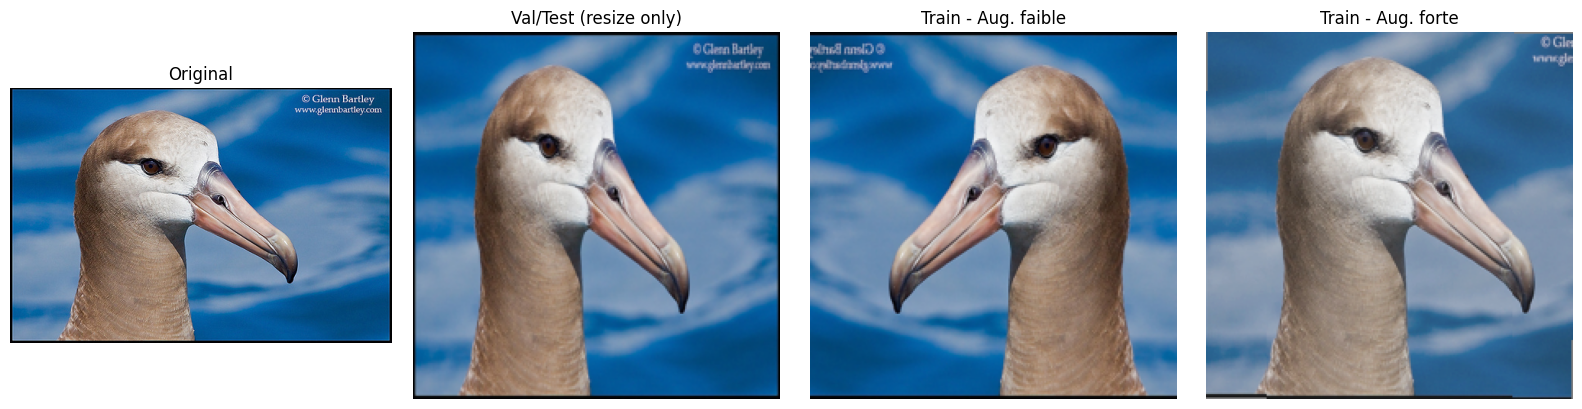

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prendre une image d'exemple
sample_img_path = df['image_path'].iloc[0]
original = Image.open(sample_img_path).convert('RGB')

def denormalize(tensor):
    """Inverse la normalisation pour pouvoir afficher l'image"""
    mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
    std = np.array(IMAGENET_STD).reshape(3,1,1)
    img = tensor.numpy() * std + mean
    img = np.clip(img, 0, 1)
    return np.transpose(img, (1,2,0))

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(denormalize(val_transform(original)))
axes[1].set_title("Val/Test (resize only)")
axes[1].axis('off')

axes[2].imshow(denormalize(train_transform_weak(original)))
axes[2].set_title("Train - Aug. faible")
axes[2].axis('off')

axes[3].imshow(denormalize(train_transform_strong(original)))
axes[3].set_title("Train - Aug. forte")
axes[3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_transforms_preview.png', dpi=200)
plt.show()

### la classe Dataset PyTorch

In [13]:
from torch.utils.data import Dataset
from PIL import Image

LABEL_MAP = {c: i for i, c in enumerate(sorted(df['class_id'].unique()))}

class CUBDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=LABEL_MAP):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.label_map[row['class_id']]
        return img, label

### test rapide de la classe

In [14]:
train_ds = CUBDataset(train, transform=train_transform_weak)
val_ds = CUBDataset(val, transform=val_transform)

img, label = train_ds[0]
print(f"Shape: {img.shape}, Label: {label}, dtype: {img.dtype}")

Shape: torch.Size([3, 224, 224]), Label: 31, dtype: torch.float32


### DataLoader

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

images_batch, labels_batch = next(iter(train_loader))
print(f"Batch images: {images_batch.shape}")  # attendu : [32, 3, 224, 224]
print(f"Batch labels: {labels_batch.shape}")  # attendu : [32]
print(f"Labels min/max: {labels_batch.min().item()} / {labels_batch.max().item()}")

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])
Labels min/max: 0 / 198


### MLFlow

In [16]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

### logging MLflow

In [18]:
import mlflow

# Backend SQLite sur Drive partagé — toute l'équipe pointe vers le même fichier .db
mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/Projet_annuel/mlflow.db")
mlflow.set_experiment("cub200_data_pipeline")

with mlflow.start_run(run_name="build_data_pipeline"):
    mlflow.log_param("seed", SEED)
    mlflow.log_param("val_fraction", 0.15)
    mlflow.log_param("subset_fractions", SUBSET_FRACTIONS)
    mlflow.log_param("image_size", IMAGE_SIZE)

    mlflow.log_metric("n_images_total", len(df))
    mlflow.log_metric("n_classes", df['class_id'].nunique())
    mlflow.log_metric("n_train", len(train))
    mlflow.log_metric("n_val", len(val))
    mlflow.log_metric("n_test", len(test))

    for fname in [
        "split_train.csv", "split_val.csv", "split_test.csv",
        "split_train_10pct.csv", "split_train_25pct.csv",
        "split_train_50pct.csv", "split_train_100pct.csv",
        "eda_class_distribution.png", "eda_similar_classes.png",
        "eda_transforms_preview.png",
    ]:
        path = f'{OUT_DIR}/{fname}'
        if os.path.exists(path):
            mlflow.log_artifact(path)

    print("Run MLflow loggé avec succès.")

2026/08/13 06:06:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/13 06:06:32 INFO mlflow.store.db.utils: Updating database tables
2026/08/13 06:06:37 INFO mlflow.tracking.fluent: Experiment with name 'cub200_data_pipeline' does not exist. Creating a new experiment.


Run MLflow loggé avec succès.
